***Я выбрала известный датасет "Hotel Booking Demand"(спрос на бронирование отелей). Он является "золотым стандартом" для EDA, потому что в нем есть всё: даты, деньги, категории клиентов и целевая переменная (is_canceled).***

Я уже выполняла по этому датасету лабораторную работу №2, и на основе того исследования теперь я готова выполнить работу №4 по снижению размерности пространства признаков. Оставила частично код с прошлой лабораторной работы - я уже выполняла этап исключения пустых столбцов и заполнения пропусков.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, classification_report)

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost не установлен, поэтому будем использовать AdaBoost вместо него")

import warnings
warnings.filterwarnings('ignore')


XGBoost не установлен, поэтому будем использовать AdaBoost вместо него


In [8]:
df = pd.read_csv('~/Downloads/hotel_booking_data_cleaned.csv')

In [9]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,01/07/2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,02/07/2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,03/07/2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,06/09/2017
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,07/09/2017
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,07/09/2017
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,07/09/2017


In [10]:
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,21/10/2015
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


### Анализ структуры данных

Датасет содержит **119 390 записей** и **32 признака**.

**Проблемы с данными, выявленные на этапе df.info():**
1. **Критичные пропуски:** 
   - `company` (94% пропусков) - столбец будет удален из анализа ввиду полной неинформативности.
   - `agent` (13% пропусков) - столбец исключен из визуализации корреляций, т.к. содержит ID.
2. **Незначительные пропуски:**
   - `children` (4 пропуска) - будут заполнены медианой (0).
   - `country` (488 пропусков) - будут заменены на моду (самое частое значение) или метку 'UNK'.
3. **Типы данных:**
   - Колонка `children` имеет тип **float64**, хотя должна быть **int64**. Это говорит о наличии значений `NaN`. После обработки пропусков тип будет изменен.
   - Колонка `arrival_date_month` имеет тип **object**. Для корректной сортировки в графиках он будет преобразован в категориальный тип с правильным порядком месяцев.

**Итог:** Для непосредственного EDA будет использовано **30 признаков** после удаления `company` и `agent`.

In [11]:
df.drop(['company', 'agent'], axis=1, inplace=True) # Удаляем бесполезные столбцы
df['children'] = df['children'].fillna(0) # Заполняем пропуски нулями
df['country'] = df['country'].fillna('Unknown') #здесь заполняем неизвестно
df['children'] = df['children'].astype(int) # Меняем тип children на int
print(df.isnull().sum().sum())  # выводится ноль, а это значит, что пропусков больше нет, у нас осталось 30 столбцов

0


In [12]:
y = df['is_canceled'] #целевая переменная
drop_cols = ['is_canceled', 'reservation_status', 'reservation_status_date']
# если есть ещё столбцы, которые не несут пользы (например, имена или ID), их тоже убрать
X = df.drop(columns=drop_cols, errors='ignore')

print("Признаки (X), количество строк и столбцов:", X.shape)
print("Целевая переменная (y), количество строк:", y.shape)

Признаки (X), количество строк и столбцов: (119390, 27)
Целевая переменная (y), количество строк: (119390,)


In [13]:
# Разделяем колонки на числовые и категориальные
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n Всего признаков: {X.shape[1]}")
print(f"   Числовых:      {len(num_cols)}")
print(f"   Категориальных: {len(cat_cols)}")

print("\n Числовые признаки:")
if num_cols:
    num_str = ", ".join(num_cols)
    if len(num_str) > 80:
        print("   " + "\n   ".join(num_str[i:i+80] for i in range(0, len(num_str), 80)))
    else:
        print(f"   {num_str}")

print("\n Категориальные признаки:")
if cat_cols:
    cat_info = []
    for col in cat_cols:
        unique_count = X[col].nunique()
        cat_info.append(f"{col} ({unique_count} уник.)")
    print("   " + "\n   ".join(cat_info))


# Применяем One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"\n Размерность ДО кодирования:")
print(f"   Строк:  {X.shape[0]}")
print(f"   Столбцов: {X.shape[1]}")

print(f"\n Размерность ПОСЛЕ кодирования (One-Hot Encoding):")
print(f"   Строк:  {X_encoded.shape[0]} (без изменений)")
print(f"   Столбцов: {X_encoded.shape[1]} (+{X_encoded.shape[1] - X.shape[1]})")

#пример новых столбцов
new_cols = [c for c in X_encoded.columns if c not in num_cols and c not in cat_cols]
if len(new_cols) > 0:
    print(f"\nДобавлено бинарных признаков: {len(new_cols)}")
    sample_new = new_cols[:10]
    print("   Примеры новых столбцов:")
    for col in sample_new:
        print(f"       {col}")
    if len(new_cols) > 10:
        print(f"       ... и ещё {len(new_cols) - 10}")



 Всего признаков: 27
   Числовых:      17
   Категориальных: 10

 Числовые признаки:
   lead_time, arrival_date_year, arrival_date_week_number, arrival_date_day_of_mont
   h, stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, is_r
   epeated_guest, previous_cancellations, previous_bookings_not_canceled, booking_c
   hanges, days_in_waiting_list, adr, required_car_parking_spaces, total_of_special
   _requests

 Категориальные признаки:
   hotel (2 уник.)
   arrival_date_month (12 уник.)
   meal (5 уник.)
   country (178 уник.)
   market_segment (8 уник.)
   distribution_channel (5 уник.)
   reserved_room_type (10 уник.)
   assigned_room_type (12 уник.)
   deposit_type (3 уник.)
   customer_type (4 уник.)

 Размерность ДО кодирования:
   Строк:  119390
   Столбцов: 27

 Размерность ПОСЛЕ кодирования (One-Hot Encoding):
   Строк:  119390 (без изменений)
   Столбцов: 246 (+219)

Добавлено бинарных признаков: 229
   Примеры новых столбцов:
       hotel_Resort Hotel
  

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")

Обучающая выборка: 95512 записей
Тестовая выборка: 23878 записей


In [15]:
# Словарь с моделями
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
}

if xgb_available:
    models['XGBoost'] = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                      random_state=42, use_label_encoder=False, eval_metric='logloss')
else:
    models['AdaBoost'] = AdaBoostClassifier(n_estimators=100, random_state=42)

# Обучаем и собираем предсказания
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    print(f"Модель {name} обучена")

Модель Decision Tree обучена
Модель Random Forest обучена
Модель AdaBoost обучена



 Decision Tree
Accuracy(правильность):  0.7984
Precision(точность): 0.7056
Recall(чувствительность):    0.7821
F1-score(гармонизированная мера точности и полноты.):  0.7419
AUC-ROC(площадь под кривой рабочего характеристического показателя приемника):   0.8749


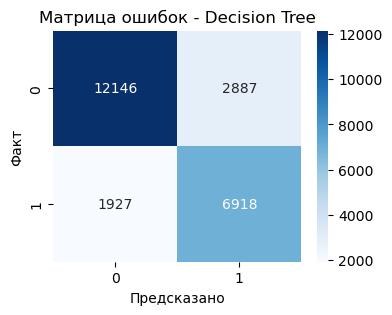


 Random Forest
Accuracy(правильность):  0.7919
Precision(точность): 0.9543
Recall(чувствительность):    0.4603
F1-score(гармонизированная мера точности и полноты.):  0.6210
AUC-ROC(площадь под кривой рабочего характеристического показателя приемника):   0.9156


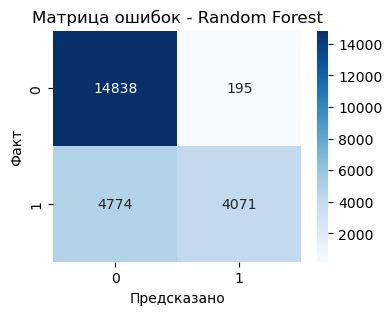


 AdaBoost
Accuracy(правильность):  0.8151
Precision(точность): 0.8216
Recall(чувствительность):    0.6398
F1-score(гармонизированная мера точности и полноты.):  0.7194
AUC-ROC(площадь под кривой рабочего характеристического показателя приемника):   0.8927


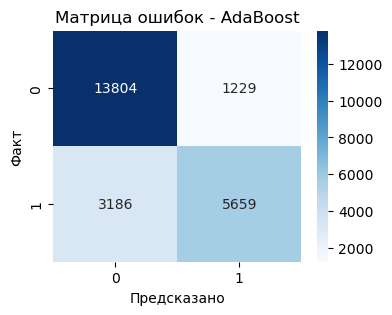

\СВОДНАЯ ТАБЛИЦА МЕТРИК
               Accuracy  Precision  Recall      F1     AUC
Model                                                     
Decision Tree    0.7984     0.7056  0.7821  0.7419  0.8749
Random Forest    0.7919     0.9543  0.4603  0.6210  0.9156
AdaBoost         0.8151     0.8216  0.6398  0.7194  0.8927


In [16]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n {name}")
    print(f"Accuracy(правильность):  {acc:.4f}")
    print(f"Precision(точность): {prec:.4f}")
    print(f"Recall(чувствительность):    {rec:.4f}")
    print(f"F1-score(гармонизированная мера точности и полноты.):  {f1:.4f}")
    
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba[:, 1])
        print(f"AUC-ROC(площадь под кривой рабочего характеристического показателя приемника):   {auc:.4f}")
    else:
        auc = None
    
    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Матрица ошибок - {name}')
    plt.xlabel('Предсказано')
    plt.ylabel('Факт')
    plt.show()
    
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}

results = []
for name, model in models.items():
    y_pred = predictions[name]
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
    else:
        y_proba = None
    metrics = evaluate_model(name, y_test, y_pred, y_proba)
    metrics['Model'] = name
    results.append(metrics)

# Сводная таблица
results_df = pd.DataFrame(results).set_index('Model')
print("\СВОДНАЯ ТАБЛИЦА МЕТРИК")
print(results_df.round(4))

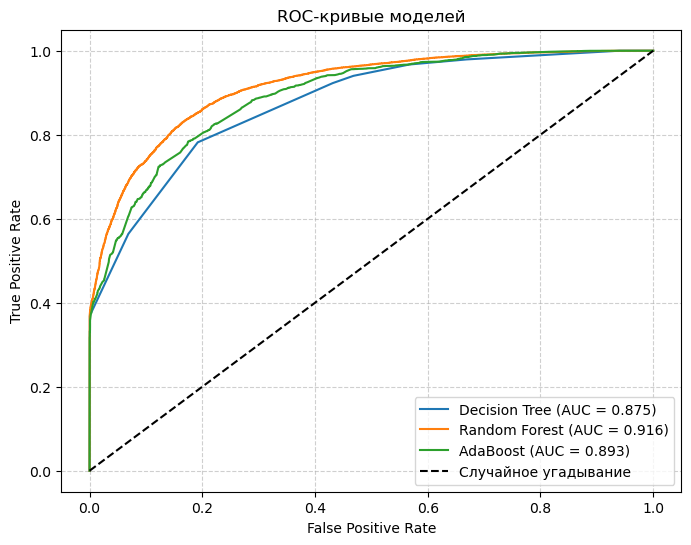

In [17]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    else:
        # Для AdaBoost тоже есть predict_proba
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

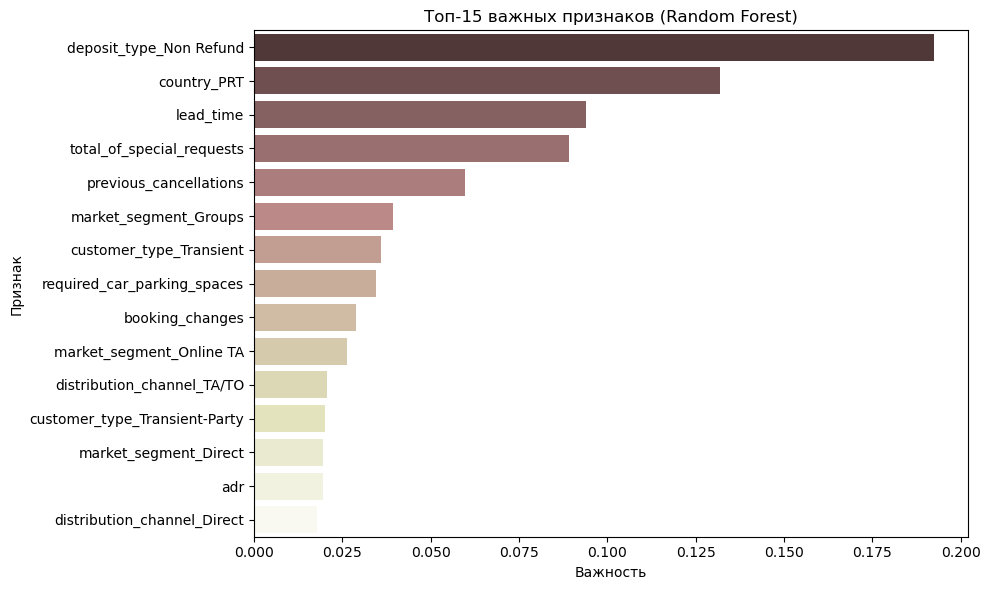

In [18]:
# Для Random Forest можно легко получить Feature Importance
model_for_importance = models['Random Forest']  # или 'XGBoost' если есть
importances = model_for_importance.feature_importances_
feature_names = X_encoded.columns

# Создаём DataFrame и сортируем
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='pink')
plt.title('Топ-15 важных признаков (Random Forest)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

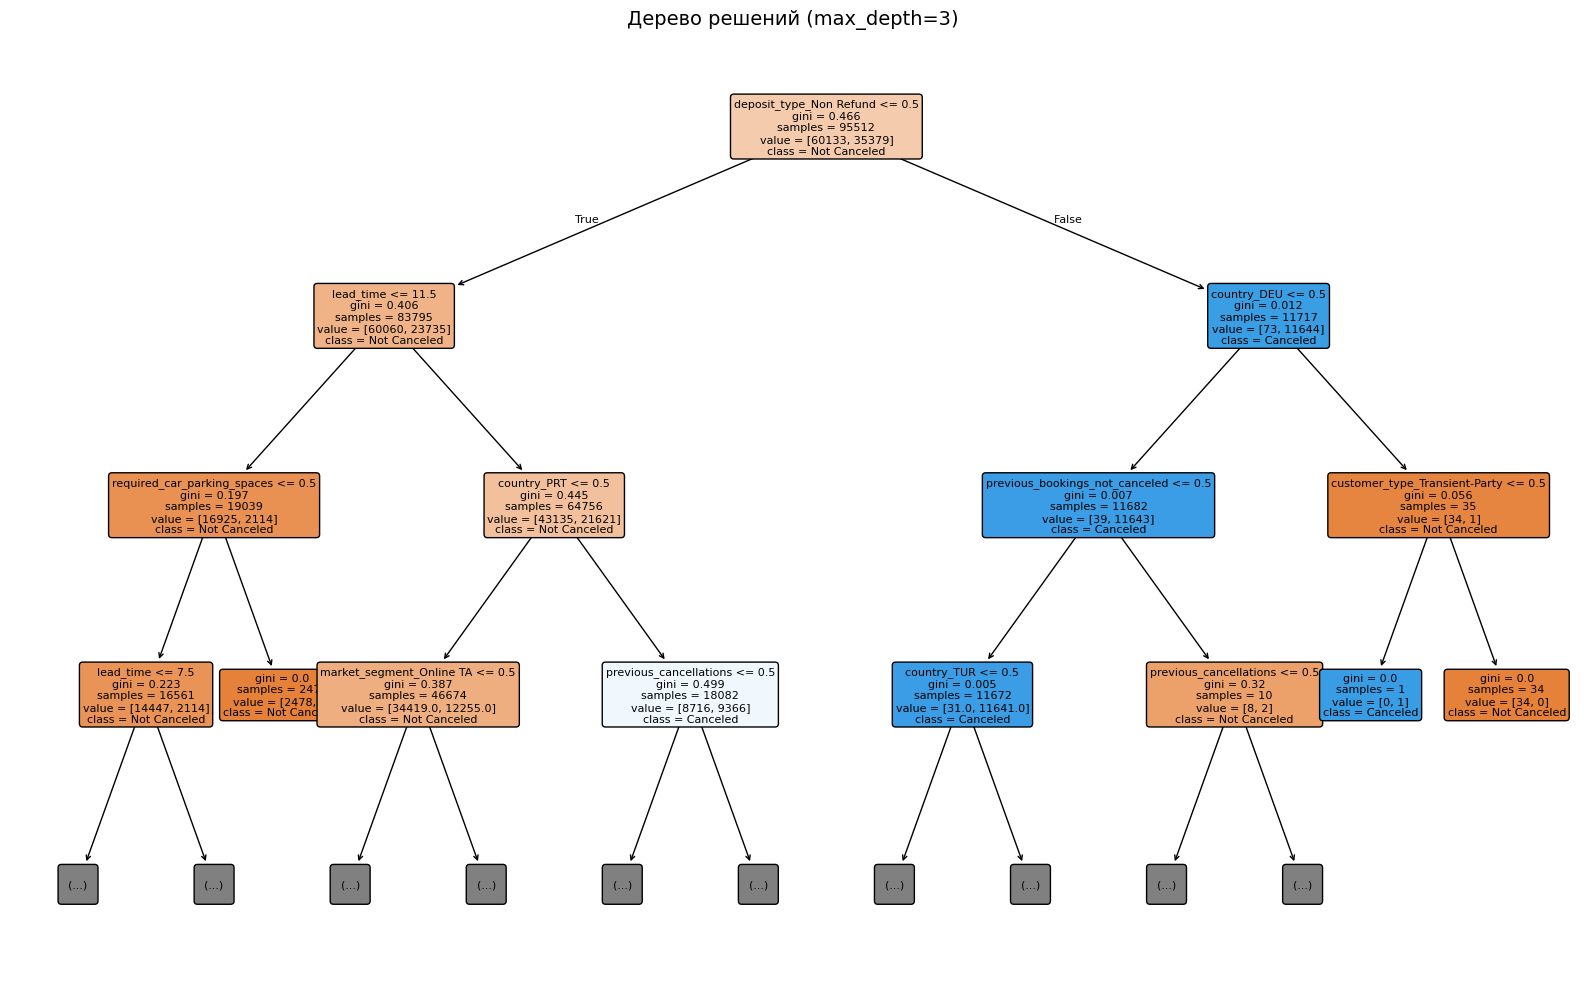

In [19]:
plt.figure(figsize=(16, 10))
tree_plot = plot_tree(models['Decision Tree'], 
                      feature_names=X_encoded.columns, 
                      class_names=['Not Canceled', 'Canceled'],
                      filled=True, 
                      rounded=True, 
                      fontsize=8,
                      max_depth=3)  
plt.title('Дерево решений (max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()